In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import norm
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

import joblib


In [ ]:
BINS   = [0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100]
LABELS = ["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]

def bucket_mae(df, preds):
    """MAE by moneyness bucket for each model; last row = all options."""
    t = pd.DataFrame({"bucket": pd.cut(df["moneyness (S/K)"], bins=BINS, labels=LABELS)})
    for k, p in preds.items():
        t[k] = np.abs(df["price"].values - np.asarray(p))
    out = t.groupby("bucket", observed=True).mean()
    out.insert(0, "n", t.groupby("bucket", observed=True).size())
    out.loc["ALL"] = [len(t)] + list(t.drop(columns="bucket").mean())
    return out.astype({"n": int})

In [ ]:
aapl = pd.read_csv("AAPL_cleaned.csv")
aapl["date"] = pd.to_datetime(aapl["date"])
aapl["exdate"] = pd.to_datetime(aapl["exdate"])

print(aapl.shape)
aapl.head()

(838276, 19)


,secid,date,exdate,strike_price,best_bid,best_offer,volume,open_interest,optionid,close,moneyness (S/K),price,volatility,rate,days_to_maturity,T,last_dividend,frequency,q
0,101594,2020-08-31,2020-09-04,100.00,29.4,29.7,150,411,135212375,129.04,1.290400,29.55,0.375779,0.002148,4,0.010959,0.205,3,0.004766
1,101594,2020-08-31,2020-11-20,80.00,50.1,50.5,0,343,134244951,129.04,1.613000,50.30,0.375779,0.002148,81,0.221918,0.205,3,0.004766
2,101594,2020-08-31,2020-11-20,81.25,48.9,49.3,1,416,134244952,129.04,1.588185,49.10,0.375779,0.002148,81,0.221918,0.205,3,0.004766
3,101594,2020-08-31,2020-11-20,82.50,47.7,48.1,16,383,134244953,129.04,1.564121,47.90,0.375779,0.002148,81,0.221918,0.205,3,0.004766
4,101594,2020-08-31,2020-11-20,83.75,46.5,46.9,0,414,134244954,129.04,1.540776,46.70,0.375779,0.002148,81,0.221918,0.205,3,0.004766


In [ ]:
aapl = aapl.sort_values("date").reset_index(drop=True)

train_cutoff = aapl["date"].quantile(0.70)
val_cutoff = aapl["date"].quantile(0.85)

train = aapl[aapl["date"] <= train_cutoff]
val = aapl[(aapl["date"] > train_cutoff) & (aapl["date"] <= val_cutoff)]
test = aapl[aapl["date"] > val_cutoff]

print(f"Train: {len(train)} rows, {train['date'].min()} to {train['date'].max()}")
print(f"Validation: {len(val)} rows, {val['date'].min()} to {val['date'].max()}")
print(f"Test: {len(test)} rows, {test['date'].min()} to {test['date'].max()}")

Train: 587104 rows, 2020-08-31 00:00:00 to 2024-03-27 00:00:00
Validation: 125955 rows, 2024-03-28 00:00:00 to 2024-12-26 00:00:00
Test: 125217 rows, 2024-12-27 00:00:00 to 2025-08-29 00:00:00


In [ ]:
feature_cols = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
target_col = "price"

X_train, y_train = train[feature_cols], train[target_col]
X_val, y_val = val[feature_cols], val[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print("Feature columns:", feature_cols)
print("Target column:", target_col)

Feature columns: ['moneyness (S/K)', 'T', 'rate', 'q', 'volatility']
Target column: price


# Neural Network

In [ ]:
train[["moneyness (S/K)", "strike_price"]].corr()

,moneyness (S/K),strike_price
moneyness (S/K),1.000000,-0.576018
strike_price,-0.576018,1.000000


The two inputs are not so correlated, we can add K as an input

## 1. Experiment (v1): 6 inputs + raw target

## 6 features + raw target

In [ ]:
# ============================================================
# Neural Network with all 5 features (production candidate) — AAPL
# ============================================================

feature_cols_nn = ["moneyness (S/K)", "strike_price", "T", "rate", "q", "volatility"]
target_col = "price"

X_train_full5 = train[feature_cols_nn].values
y_train_full5_log = np.log1p(train[target_col].values)
X_val5 = val[feature_cols_nn].values
y_val5 = val[target_col].values

scaler5 = StandardScaler()
X_train_full5_scaled = scaler5.fit_transform(X_train_full5)
X_val5_scaled = scaler5.transform(X_val5)

selection_results5 = []

for n_units in range(1, 15):
    model = MLPRegressor(
        hidden_layer_sizes=(n_units,),
        activation="logistic",
        solver="adam",
        max_iter=2000,
        batch_size=2000,
        early_stopping=True,
        n_iter_no_change=15,
        random_state=42
    )
    model.fit(X_train_full5_scaled, y_train_full5_log)
    val_pred_log = model.predict(X_val5_scaled)
    val_pred = np.expm1(val_pred_log)
    val_rmse = np.sqrt(mean_squared_error(y_val5, val_pred))
    print(f"n_units={n_units}: val_rmse={val_rmse:.4f}, n_iter={model.n_iter_}, hit_max={model.n_iter_ >= 2000}")
    selection_results5.append({"n_units": n_units, "val_rmse": val_rmse})

n_units=1: val_rmse=34.0682, n_iter=54, hit_max=False
n_units=2: val_rmse=24.6079, n_iter=72, hit_max=False
n_units=3: val_rmse=21.5720, n_iter=69, hit_max=False
n_units=4: val_rmse=17.9344, n_iter=74, hit_max=False
n_units=5: val_rmse=17.1138, n_iter=70, hit_max=False
n_units=6: val_rmse=15.3667, n_iter=76, hit_max=False
n_units=7: val_rmse=15.7632, n_iter=66, hit_max=False
n_units=8: val_rmse=15.8217, n_iter=72, hit_max=False
n_units=9: val_rmse=11.8559, n_iter=69, hit_max=False
n_units=10: val_rmse=11.9702, n_iter=73, hit_max=False
n_units=11: val_rmse=11.1067, n_iter=80, hit_max=False
n_units=12: val_rmse=12.8873, n_iter=67, hit_max=False
n_units=13: val_rmse=9.1612, n_iter=76, hit_max=False
n_units=14: val_rmse=12.3341, n_iter=67, hit_max=False


9 neurons is a solid choice base on the elbow method

In [ ]:
best_n_units6 = 9

train_val = pd.concat([train, val], ignore_index=True)

X_train_val6 = train_val[feature_cols_nn].values
y_train_val6_log = np.log1p(train_val[target_col].values)
X_test6 = test[feature_cols_nn].values
y_test6 = test[target_col].values

scaler6_final = StandardScaler()
X_train_val6_scaled = scaler6_final.fit_transform(X_train_val6)
X_test6_scaled = scaler6_final.transform(X_test6)

nn_model6 = MLPRegressor(
    hidden_layer_sizes=(best_n_units6,),
    activation="logistic",
    solver="adam",
    max_iter=2000,
    batch_size=2000,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)
nn_model6.fit(X_train_val6_scaled, y_train_val6_log)

y_pred_nn6_log = nn_model6.predict(X_test6_scaled)
y_pred_nn6 = np.expm1(y_pred_nn6_log)

nn6_rmse = np.sqrt(mean_squared_error(y_test6, y_pred_nn6))
nn6_mae = mean_absolute_error(y_test6, y_pred_nn6)

print(f"Neural Network (6 features, {best_n_units6} hidden units) — AAPL Test set")
print(f"RMSE: {nn6_rmse:.4f}")
print(f"MAE:  {nn6_mae:.4f}")

Neural Network (6 features, 9 hidden units) — AAPL Test set
RMSE: 8.2880
MAE:  4.8228


In [ ]:
nn6_check = test.copy()
nn6_check["nn6_pred"] = y_pred_nn6
nn6_check["nn6_error_abs"] = np.abs(nn6_check["price"] - nn6_check["nn6_pred"])
nn6_check["nn6_error_pct"] = (nn6_check["nn6_error_abs"] / nn6_check["price"]) * 100

nn6_check["moneyness_bucket"] = pd.cut(
    nn6_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

nn6_bucket_summary = nn6_check.groupby("moneyness_bucket").agg(
    n_options=("nn6_error_abs", "size"),
    nn6_mae=("nn6_error_abs", "mean"),
    nn6_mape=("nn6_error_pct", "mean"),
)
nn6_bucket_summary["pct_of_test"] = (nn6_bucket_summary["n_options"] / nn6_bucket_summary["n_options"].sum()) * 100

nn6_bucket_summary

/tmp/ipykernel_9990/1743780027.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nn6_bucket_summary = nn6_check.groupby("moneyness_bucket").agg(


,n_options,nn6_mae,nn6_mape,pct_of_test
moneyness_bucket,,,,
Deep OTM,26376,0.256267,227.414169,21.064232
OTM,22324,1.470507,139.651413,17.828250
ATM,13178,4.127913,57.068738,10.524130
ITM,15059,6.000589,23.951834,12.026322
Deep ITM,31571,6.670646,9.197055,25.213030
Very Deep ITM,11824,7.978121,5.584262,9.442807
Extreme ITM,4885,23.463899,11.944969,3.901227


In [ ]:
# actual price distribution in the Deep OTM bucket (test set)
deep_otm = test[test["moneyness (S/K)"] <= 0.8]
print(deep_otm["price"].describe())
print("\nquantiles:", deep_otm["price"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(3).to_dict())

count    26376.000000
mean         0.616348
std          0.994470
min          0.010000
25%          0.055000
50%          0.200000
75%          0.700000
max          9.300000
Name: price, dtype: float64

quantiles: {0.1: 0.025, 0.25: 0.055, 0.5: 0.2, 0.75: 0.7, 0.9: 1.785}


In [ ]:
# is the MAPE driven by the bucket as a whole, or by the cheapest options?
deep_otm_pred = y_pred_nn6[test["moneyness (S/K)"].values <= 0.8]
ape = np.abs(deep_otm["price"].values - deep_otm_pred) / deep_otm["price"].values * 100
print("mean APE:", ape.mean().round(1))
print("median APE:", np.median(ape).round(1))

mean APE: 227.4
median APE: 58.7


Training error

In [ ]:
y_train_val6 = train_val[target_col].values
y_pred_train6 = np.expm1(nn_model6.predict(X_train_val6_scaled))

train_rmse_nn6 = np.sqrt(mean_squared_error(y_train_val6, y_pred_train6))
train_mae_nn6 = mean_absolute_error(y_train_val6, y_pred_train6)

print(f"Train RMSE: {train_rmse_nn6:.4f}   Test RMSE: {nn6_rmse:.4f}")
print(f"Train MAE:  {train_mae_nn6:.4f}   Test MAE:  {nn6_mae:.4f}")
print(f"Ratio test/train RMSE: {nn6_rmse/train_rmse_nn6:.2f}x")


Train RMSE: 4.4580   Test RMSE: 8.2880
Train MAE:  2.4021   Test MAE:  4.8228
Ratio test/train RMSE: 1.86x


In [ ]:
print(train_val["price"].describe())
print("share under $2.40:", (train_val["price"] < 2.40).mean().round(3))

count    713059.000000
mean         33.274190
std          40.081384
min           0.010000
25%           1.250000
50%          16.100000
75%          55.100000
max         254.550000
Name: price, dtype: float64
share under $2.40: 0.295


Il 29.5% del campione vale meno di 2.40 dollari. Il 25° percentile è 1.25. Quindi su quasi un terzo delle osservazioni, l'errore medio del modello è più grande del prezzo dell'opzione. Non è una coda marginale: sono 210mila osservazioni su 713mila.
Quindi anche se MAE 2.40 può sembrare basso in realtà non lo è --> dimostra un leggero underfitting
Ipotesi:
la formulazione con target grezzo produce un errore di training sostanzialmente più alto a parità di architettura, indicando che la difficoltà non risiede nella capacità del modello ma nella rappresentabilità della funzione obiettivo.

There is no improvement against XGBoost, so another hypothesis: what is the model tries to predict price/K instead of only price ?

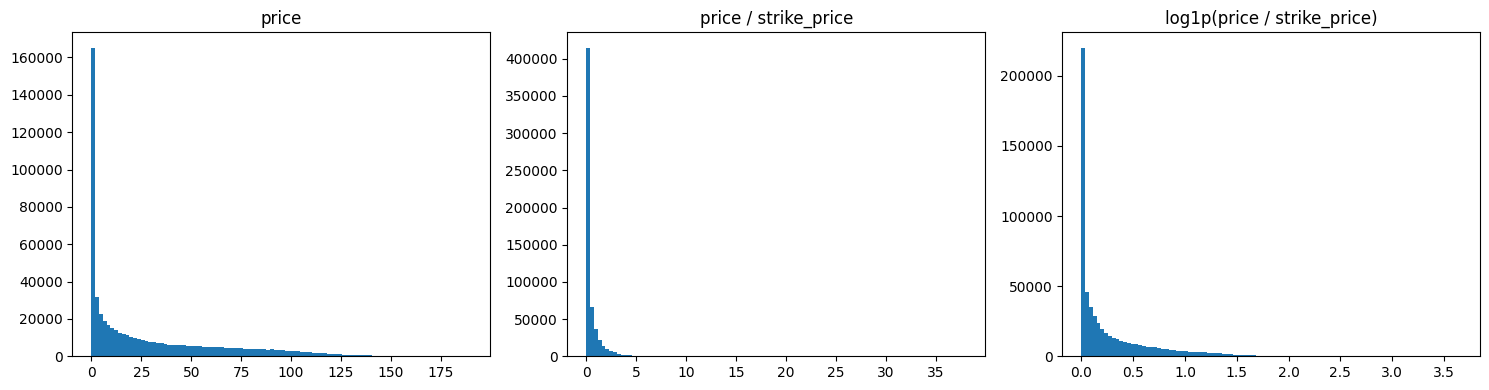

price:
count    587104.000000
mean         29.949595
std          35.017883
min           0.010000
25%           1.215000
50%          14.775000
75%          50.325000
max         190.175000
dtype: float64

price/K:
count    587104.000000
mean          0.451058
std           1.114913
min           0.000047
25%           0.006764
50%           0.106801
75%           0.493750
max          38.035000
dtype: float64

log1p(price/K):
count    587104.000000
mean          0.273625
std           0.380796
min           0.000047
25%           0.006742
50%           0.101474
75%           0.401290
max           3.664459
dtype: float64


In [ ]:
price = train["price"].values
price_over_k = train["price"].values / train["strike_price"].values
log_price_over_k = np.log1p(price_over_k)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(price, bins=100)
axes[0].set_title("price")

axes[1].hist(price_over_k, bins=100)
axes[1].set_title("price / strike_price")

axes[2].hist(log_price_over_k, bins=100)
axes[2].set_title("log1p(price / strike_price)")

plt.tight_layout()
plt.show()

print("price:")
print(pd.Series(price).describe())
print("\nprice/K:")
print(pd.Series(price_over_k).describe())
print("\nlog1p(price/K):")
print(pd.Series(log_price_over_k).describe())

## 6 featrues + price normalized for strike

In [ ]:
# ============================================================
# Neural Network — target normalized by strike (price/K), 6 features — AAPL
# ============================================================

feature_cols_nn6 = ["moneyness (S/K)", "strike_price", "T", "rate", "q", "volatility"]

X_train_full6 = train[feature_cols_nn6].values
y_train_ratio = train["price"].values / train["strike_price"].values
y_train_ratio_log = np.log1p(y_train_ratio)

X_val6 = val[feature_cols_nn6].values
y_val_ratio = val["price"].values / val["strike_price"].values
y_val_price = val["price"].values   # keep raw price for RMSE evaluation

scaler6b = StandardScaler()
X_train_full6_scaled = scaler6b.fit_transform(X_train_full6)
X_val6_scaled = scaler6b.transform(X_val6)

selection_results6b = []

for n_units in range(1, 21):
    model = MLPRegressor(
        hidden_layer_sizes=(n_units,),
        activation="logistic",
        solver="adam",
        max_iter=2000,
        batch_size=2000,
        early_stopping=True,
        n_iter_no_change=15,
        random_state=42
    )
    model.fit(X_train_full6_scaled, y_train_ratio_log)
    val_pred_ratio_log = model.predict(X_val6_scaled)
    val_pred_ratio = np.expm1(val_pred_ratio_log)
    val_pred_price = val_pred_ratio * val["strike_price"].values   # multiply back by K
    val_rmse = np.sqrt(mean_squared_error(y_val_price, val_pred_price))
    print(f"n_units={n_units}: val_rmse={val_rmse:.4f}, n_iter={model.n_iter_}, hit_max={model.n_iter_ >= 2000}")
    selection_results6b.append({"n_units": n_units, "val_rmse": val_rmse})

selection_df6b = pd.DataFrame(selection_results6b).sort_values("val_rmse")
best_n_units6b = int(selection_df6b.iloc[0]["n_units"])
print(f"\nBest hidden units (lowest val RMSE): {best_n_units6b}")

n_units=1: val_rmse=27.3272, n_iter=53, hit_max=False
n_units=2: val_rmse=14.6867, n_iter=73, hit_max=False
n_units=3: val_rmse=9.2619, n_iter=58, hit_max=False
n_units=4: val_rmse=6.7020, n_iter=69, hit_max=False
n_units=5: val_rmse=5.5576, n_iter=53, hit_max=False
n_units=6: val_rmse=6.0058, n_iter=48, hit_max=False
n_units=7: val_rmse=5.9077, n_iter=41, hit_max=False
n_units=8: val_rmse=6.3355, n_iter=55, hit_max=False
n_units=9: val_rmse=5.9335, n_iter=52, hit_max=False
n_units=10: val_rmse=5.2197, n_iter=39, hit_max=False
n_units=11: val_rmse=5.4828, n_iter=40, hit_max=False


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


n_units=12: val_rmse=12.8025, n_iter=10, hit_max=False


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


n_units=13: val_rmse=18.0195, n_iter=5, hit_max=False


...

n_units=15: val_rmse=22.3323, n_iter=2, hit_max=False


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


n_units=16: val_rmse=13.6891, n_iter=7, hit_max=False


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


n_units=17: val_rmse=34.3558, n_iter=2, hit_max=False


In [ ]:
best_n_units6b = 14

train_val = pd.concat([train, val], ignore_index=True)

X_train_val6 = train_val[feature_cols_nn6].values
y_train_val_ratio = train_val["price"].values / train_val["strike_price"].values
y_train_val_ratio_log = np.log1p(y_train_val_ratio)

X_test6 = test[feature_cols_nn6].values
y_test_price = test["price"].values

scaler6b_final = StandardScaler()
X_train_val6_scaled = scaler6b_final.fit_transform(X_train_val6)
X_test6_scaled = scaler6b_final.transform(X_test6)

nn_model6b = MLPRegressor(
    hidden_layer_sizes=(best_n_units6b,),
    activation="logistic",
    solver="adam",
    max_iter=2000,
    batch_size=2000,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)
nn_model6b.fit(X_train_val6_scaled, y_train_val_ratio_log)

y_pred_ratio_log = nn_model6b.predict(X_test6_scaled)
y_pred_ratio = np.expm1(y_pred_ratio_log)
y_pred_nn6b = y_pred_ratio * test["strike_price"].values

nn6b_rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_nn6b))
nn6b_mae = mean_absolute_error(y_test_price, y_pred_nn6b)

print(f"Neural Network (normalized target, {best_n_units6b} hidden units) — AAPL Test set")
print(f"RMSE: {nn6b_rmse:.4f}")
print(f"MAE:  {nn6b_mae:.4f}")

In [ ]:
nn6b_check = test.copy()
nn6b_check["nn6b_pred"] = y_pred_nn6b
nn6b_check["nn6b_error_abs"] = np.abs(nn6b_check["price"] - nn6b_check["nn6b_pred"])
nn6b_check["nn6b_error_pct"] = (nn6b_check["nn6b_error_abs"] / nn6b_check["price"]) * 100

nn6b_check["moneyness_bucket"] = pd.cut(
    nn6b_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

nn6b_bucket_summary = nn6b_check.groupby("moneyness_bucket").agg(
    n_options=("nn6b_error_abs", "size"),
    nn6b_mae=("nn6b_error_abs", "mean"),
    nn6b_mape=("nn6b_error_pct", "mean"),
)
nn6b_bucket_summary["pct_of_test"] = (nn6b_bucket_summary["n_options"] / nn6b_bucket_summary["n_options"].sum()) * 100

nn6b_bucket_summary

Training error:

In [ ]:
# Train vs test error — AAPL Neural Network (normalized target)
y_pred_train_ratio_log = nn_model6b.predict(X_train_val6_scaled)
y_pred_train_ratio = np.expm1(y_pred_train_ratio_log)
y_pred_train_price = y_pred_train_ratio * train_val["strike_price"].values
y_train_val_price = train_val["price"].values

train_rmse_nn = np.sqrt(mean_squared_error(y_train_val_price, y_pred_train_price))
train_mae_nn = mean_absolute_error(y_train_val_price, y_pred_train_price)

print(f"AAPL NN — Train (train+val): RMSE={train_rmse_nn:.4f}, MAE={train_mae_nn:.4f}")
print(f"AAPL NN — Test:              RMSE={nn6b_rmse:.4f}, MAE={nn6b_mae:.4f}")
print(f"Ratio test/train RMSE: {nn6b_rmse/train_rmse_nn:.2f}x")

In [ ]:
# implied error in normalized units for the Deep OTM bucket
dotm = test[test["moneyness (S/K)"] <= 0.8]
dotm_pred = y_pred_nn6b[test["moneyness (S/K)"].values <= 0.8]
err_norm = np.abs(dotm["price"].values - dotm_pred) / dotm["strike_price"].values
print("median |error| in price/K units:", np.median(err_norm).round(5))
print("median K in this bucket:", dotm["strike_price"].median())
print("target price/K in this bucket — median:", (dotm["price"]/dotm["strike_price"]).median().round(5))

In [ ]:
# distribution of K by moneyness bucket (train+val)
tmp = train_val.copy()
tmp["bucket"] = pd.cut(tmp["moneyness (S/K)"], bins=[0,0.8,0.95,1.05,1.2,2,5,100],
                       labels=["Deep OTM","OTM","ATM","ITM","Deep ITM","Very Deep ITM","Extreme ITM"])

print(tmp.groupby("bucket")["strike_price"].describe()[["count","min","25%","50%","75%","max"]])
print()
print(tmp.groupby("bucket").apply(
    lambda g: pd.Series({
        "median_K": g["strike_price"].median(),
        "median_price": g["price"].median(),
        "median_price_over_K": (g["price"]/g["strike_price"]).median()
    })
))

# Ordered Notebook

The four specifications below combine two choices: whether the target is the price in dollars or the price divided by the strike, and whether it is log-transformed. The dollar-scale ones take the strike as a sixth input, since the other five are unchanged when S and K are scaled together. The number of hidden units is selected on the normalized log specification and reused for the others.

## 1.1 Experiment (v1): 6 features + raw target - Baseline

In [ ]:
# ============================================================
# Neural Network — 6 features, raw target (price) — AAPL
# ============================================================

feature_cols_1 = ["moneyness (S/K)", "strike_price", "T", "rate", "q", "volatility"]
target_col = "price"

X_train_1 = train[feature_cols_1].values
X_val_1 = val[feature_cols_1].values
y_train_1 = train[target_col].values.reshape(-1, 1)
y_val = val[target_col].values

scaler_1 = StandardScaler().fit(X_train_1)
X_train_1_scaled = scaler_1.transform(X_train_1)
X_val_1_scaled = scaler_1.transform(X_val_1)

y_scaler_1 = StandardScaler().fit(y_train_1)      # the raw price needs scaling too
y_train_1_scaled = y_scaler_1.transform(y_train_1).ravel()

selection_1 = []

for n_units in range(1, 21):
    model = MLPRegressor(
        hidden_layer_sizes=(n_units,), # only one layer, tuning nummber of neurons
        activation="logistic", # common choice in the literature
        solver="adam",
        max_iter=2000, # max num but there is early stopping
        batch_size=2000, # default
        early_stopping=True,
        n_iter_no_change=15,
        random_state=42
    )
    model.fit(X_train_1_scaled, y_train_1_scaled)
    val_pred = y_scaler_1.inverse_transform(model.predict(X_val_1_scaled).reshape(-1, 1)).ravel()
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    print(f"n_units={n_units}: val_rmse={val_rmse:.4f}, n_iter={model.n_iter_}, hit_max={model.n_iter_ >= 2000}")
    selection_1.append({"n_units": n_units, "val_rmse": val_rmse})

selection_1 = pd.DataFrame(selection_1)

n_units=1: val_rmse=18.9449, n_iter=49, hit_max=False
n_units=2: val_rmse=14.1460, n_iter=58, hit_max=False
n_units=3: val_rmse=10.9607, n_iter=62, hit_max=False
n_units=4: val_rmse=9.7898, n_iter=67, hit_max=False
n_units=5: val_rmse=10.4540, n_iter=48, hit_max=False
n_units=6: val_rmse=9.3827, n_iter=44, hit_max=False
n_units=7: val_rmse=7.9697, n_iter=57, hit_max=False
n_units=8: val_rmse=12.0388, n_iter=50, hit_max=False
n_units=9: val_rmse=9.5881, n_iter=45, hit_max=False
n_units=10: val_rmse=9.6275, n_iter=49, hit_max=False
n_units=11: val_rmse=10.0494, n_iter=46, hit_max=False
n_units=12: val_rmse=9.3890, n_iter=48, hit_max=False
n_units=13: val_rmse=9.0601, n_iter=43, hit_max=False
n_units=14: val_rmse=9.2416, n_iter=48, hit_max=False
n_units=15: val_rmse=9.6999, n_iter=48, hit_max=False
n_units=16: val_rmse=9.6009, n_iter=41, hit_max=False
n_units=17: val_rmse=8.1531, n_iter=40, hit_max=False
n_units=18: val_rmse=9.2039, n_iter=39, hit_max=False
n_units=19: val_rmse=10.6297, n

In [ ]:
best_n_1 = 13   # chosen from the selection table above

model_1 = MLPRegressor(
    hidden_layer_sizes=(best_n_1,),
    activation="logistic",
    solver="adam",
    max_iter=2000,
    batch_size=2000,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)
model_1.fit(X_train_1_scaled, y_train_1_scaled)

nn_pred_1_train = y_scaler_1.inverse_transform(model_1.predict(X_train_1_scaled).reshape(-1, 1)).ravel()
nn_pred_1 = y_scaler_1.inverse_transform(model_1.predict(X_val_1_scaled).reshape(-1, 1)).ravel()

y_train_price = train[target_col].values

print(f"Neural Network (6 features, raw target, {best_n_1} hidden units) — AAPL")
print(f"Train — RMSE={np.sqrt(mean_squared_error(y_train_price, nn_pred_1_train)):.4f}  "
      f"MAE={mean_absolute_error(y_train_price, nn_pred_1_train):.4f}")
print(f"Val   — RMSE={np.sqrt(mean_squared_error(y_val, nn_pred_1)):.4f}  "
      f"MAE={mean_absolute_error(y_val, nn_pred_1):.4f}  neg={(nn_pred_1 < 0).sum()}")

Neural Network (6 features, raw target, 13 hidden units) — AAPL
Train — RMSE=1.2831  MAE=0.9585
Val   — RMSE=9.0601  MAE=5.9789  neg=10524


In [ ]:
train_bucket_1 = bucket_mae(train, {"v1": nn_pred_1_train})
val_bucket_1   = bucket_mae(val,   {"v1": nn_pred_1})

overfit_1 = pd.DataFrame({
    "n_train":   train_bucket_1["n"],
    "train_mae": train_bucket_1["v1"],
    "n_val":     val_bucket_1["n"],
    "val_mae":   val_bucket_1["v1"],
})
overfit_1["ratio_val_vs_train"] = overfit_1["val_mae"] / overfit_1["train_mae"]
overfit_1.round(3)

,n_train,train_mae,n_val,val_mae,ratio_val_vs_train
bucket,,,,,
Deep OTM,105285,0.632,20297,0.690,1.092
OTM,95876,0.832,21772,1.720,2.067
ATM,73909,1.083,14114,2.630,2.429
ITM,87994,1.028,16250,5.059,4.921
Deep ITM,144521,0.990,32936,7.194,7.266
Very Deep ITM,74966,1.272,16442,15.724,12.365
Extreme ITM,4553,1.641,4144,20.947,12.762
ALL,587104,0.958,125955,5.979,6.238


In [ ]:
# Negative predictions: the untransformed target is not constrained to positive values
n_neg = (nn_pred_1 < 0).sum()
print(f"negative predictions on validation: {n_neg} of {len(nn_pred_1)} ({n_neg / len(nn_pred_1):.2%})")
if n_neg > 0:
    print(f"min prediction: {nn_pred_1.min():.4f}")
    neg = val[nn_pred_1 < 0]
    print("\nmoneyness bucket of the negative predictions:")
    print(pd.cut(neg["moneyness (S/K)"], bins=BINS, labels=LABELS).value_counts().reindex(LABELS))
    print(f"\nactual price of these options: median {neg['price'].median():.2f}, max {neg['price'].max():.2f}")

negative predictions on validation: 10524 of 125955 (8.36%)
min prediction: -2.2062

moneyness bucket of the negative predictions:
moneyness (S/K)
Deep OTM         8760
OTM              1764
ATM                 0
ITM                 0
Deep ITM            0
Very Deep ITM       0
Extreme ITM         0
Name: count, dtype: int64

actual price of these options: median 0.10, max 2.30


## 1.2 Experiment (v2): moneyness(S/K) + K + log transformed target

In [ ]:
# ============================================================
# Neural Network — 6 features, log(C+1) target — AAPL
# ============================================================

# same inputs as v1, so the scaler can be reused
y_train_2 = np.log1p(train[target_col].values)

selection_2 = []

for n_units in range(1, 16):
    model = MLPRegressor(
        hidden_layer_sizes=(n_units,),
        activation="logistic",
        solver="adam",
        max_iter=2000,
        batch_size=2000,
        early_stopping=True,
        n_iter_no_change=15,
        random_state=42
    )
    model.fit(X_train_1_scaled, y_train_2)
    val_pred = np.expm1(model.predict(X_val_1_scaled))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    print(f"n_units={n_units}: val_rmse={val_rmse:.4f}, n_iter={model.n_iter_}, hit_max={model.n_iter_ >= 2000}")
    selection_2.append({"n_units": n_units, "val_rmse": val_rmse})

selection_2 = pd.DataFrame(selection_2)

n_units=1: val_rmse=34.0682, n_iter=54, hit_max=False
n_units=2: val_rmse=24.6079, n_iter=72, hit_max=False
n_units=3: val_rmse=21.5720, n_iter=69, hit_max=False
n_units=4: val_rmse=17.9344, n_iter=74, hit_max=False
n_units=5: val_rmse=17.1138, n_iter=70, hit_max=False
n_units=6: val_rmse=15.3667, n_iter=76, hit_max=False
n_units=7: val_rmse=15.7632, n_iter=66, hit_max=False
n_units=8: val_rmse=15.8217, n_iter=72, hit_max=False
n_units=9: val_rmse=11.8559, n_iter=69, hit_max=False
n_units=10: val_rmse=11.9702, n_iter=73, hit_max=False
n_units=11: val_rmse=11.1067, n_iter=80, hit_max=False
n_units=12: val_rmse=12.8873, n_iter=67, hit_max=False
n_units=13: val_rmse=9.1612, n_iter=76, hit_max=False
n_units=14: val_rmse=12.3341, n_iter=67, hit_max=False
n_units=15: val_rmse=11.3128, n_iter=63, hit_max=False


In [ ]:
# Fit with the selected number of units and evaluate on train and validation
best_n_2 = 10  # chosen from the selection table above

model_2 = MLPRegressor(
    hidden_layer_sizes=(best_n_2,),
    activation="logistic",
    solver="adam",
    max_iter=2000,
    batch_size=2000,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)
model_2.fit(X_train_1_scaled, y_train_2)

nn_pred_2_train = np.expm1(model_2.predict(X_train_1_scaled))
nn_pred_2 = np.expm1(model_2.predict(X_val_1_scaled))

print(f"v2 Train — RMSE={np.sqrt(mean_squared_error(y_train_price, nn_pred_2_train)):.4f}  "
      f"MAE={mean_absolute_error(y_train_price, nn_pred_2_train):.4f}")
print(f"v2 Val   — RMSE={np.sqrt(mean_squared_error(y_val, nn_pred_2)):.4f}  "
      f"MAE={mean_absolute_error(y_val, nn_pred_2):.4f}  neg={(nn_pred_2 < 0).sum()}")

v2 Train — RMSE=2.3993  MAE=1.4024
v2 Val   — RMSE=11.9702  MAE=6.9618  neg=793


In [ ]:
# MAE by moneyness bucket — train vs validation
train_bucket_2 = bucket_mae(train, {"v2": nn_pred_2_train})
val_bucket_2   = bucket_mae(val,   {"v2": nn_pred_2})

overfit_2 = pd.DataFrame({
    "n_train":   train_bucket_2["n"],
    "train_mae": train_bucket_2["v2"],
    "n_val":     val_bucket_2["n"],
    "val_mae":   val_bucket_2["v2"],
})
overfit_2["ratio_val_vs_train"] = overfit_2["val_mae"] / overfit_2["train_mae"]
overfit_2.round(3)

,n_train,train_mae,n_val,val_mae,ratio_val_vs_train
bucket,,,,,
Deep OTM,105285,0.185,20297,0.369,1.992
OTM,95876,0.458,21772,1.799,3.929
ATM,73909,0.954,14114,5.327,5.582
ITM,87994,1.131,16250,8.048,7.113
Deep ITM,144521,2.206,32936,6.616,2.999
Very Deep ITM,74966,3.131,16442,15.051,4.807
Extreme ITM,4553,7.978,4144,38.338,4.805
ALL,587104,1.402,125955,6.962,4.964


## 1.3 Experiment (v3): 5 inputs + normalized output

In [ ]:
# ============================================================
# Neural Network — 5 features, normalized target (price/K) — AAPL
# ============================================================

feature_cols_3 = ["moneyness (S/K)", "T", "rate", "q", "volatility"]

X_train_3 = train[feature_cols_3].values
X_val_3 = val[feature_cols_3].values

K_train = train["strike_price"].values
K_val = val["strike_price"].values

y_train_3 = (train[target_col].values / K_train).reshape(-1, 1)

scaler_3 = StandardScaler().fit(X_train_3)
X_train_3_scaled = scaler_3.transform(X_train_3)
X_val_3_scaled = scaler_3.transform(X_val_3)

y_scaler_3 = StandardScaler().fit(y_train_3)      # C/K is small, scaling keeps the optimiser stable
y_train_3_scaled = y_scaler_3.transform(y_train_3).ravel()

selection_3 = []

for n_units in range(1, 16):
    model = MLPRegressor(
        hidden_layer_sizes=(n_units,),
        activation="logistic",
        solver="adam",
        max_iter=2000,
        batch_size=2000,
        early_stopping=True,
        n_iter_no_change=15,
        random_state=42
    )
    model.fit(X_train_3_scaled, y_train_3_scaled)
    val_pred_ratio = y_scaler_3.inverse_transform(model.predict(X_val_3_scaled).reshape(-1, 1)).ravel()
    val_pred = val_pred_ratio * K_val
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    print(f"n_units={n_units}: val_rmse={val_rmse:.4f}, n_iter={model.n_iter_}, hit_max={model.n_iter_ >= 2000}")
    selection_3.append({"n_units": n_units, "val_rmse": val_rmse})

selection_3 = pd.DataFrame(selection_3)

n_units=1: val_rmse=17.8477, n_iter=344, hit_max=False
n_units=2: val_rmse=16.2293, n_iter=127, hit_max=False
n_units=3: val_rmse=15.6054, n_iter=109, hit_max=False
n_units=4: val_rmse=15.5440, n_iter=86, hit_max=False
n_units=5: val_rmse=10.6286, n_iter=74, hit_max=False
n_units=6: val_rmse=7.7399, n_iter=83, hit_max=False
n_units=7: val_rmse=13.9426, n_iter=67, hit_max=False
n_units=8: val_rmse=13.4978, n_iter=63, hit_max=False
n_units=9: val_rmse=9.5013, n_iter=77, hit_max=False
n_units=10: val_rmse=7.1333, n_iter=64, hit_max=False
n_units=11: val_rmse=6.9395, n_iter=57, hit_max=False
n_units=12: val_rmse=6.0944, n_iter=68, hit_max=False
n_units=13: val_rmse=6.7817, n_iter=61, hit_max=False
n_units=14: val_rmse=6.4597, n_iter=55, hit_max=False
n_units=15: val_rmse=7.3516, n_iter=59, hit_max=False


In [ ]:
# Fit with the selected number of units and evaluate on train and validation
best_n_3 = 10

model_3 = MLPRegressor(
    hidden_layer_sizes=(best_n_3,),
    activation="logistic",
    solver="adam",
    max_iter=2000,
    batch_size=2000,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)
model_3.fit(X_train_3_scaled, y_train_3_scaled)

nn_pred_3_train = y_scaler_3.inverse_transform(
    model_3.predict(X_train_3_scaled).reshape(-1, 1)).ravel() * K_train
nn_pred_3 = y_scaler_3.inverse_transform(
    model_3.predict(X_val_3_scaled).reshape(-1, 1)).ravel() * K_val

print(f"v3 Train — RMSE={np.sqrt(mean_squared_error(y_train_price, nn_pred_3_train)):.4f}  "
      f"MAE={mean_absolute_error(y_train_price, nn_pred_3_train):.4f}")
print(f"v3 Val   — RMSE={np.sqrt(mean_squared_error(y_val, nn_pred_3)):.4f}  "
      f"MAE={mean_absolute_error(y_val, nn_pred_3):.4f}  neg={(nn_pred_3 < 0).sum()}")

v3 Train — RMSE=5.0546  MAE=3.4589
v3 Val   — RMSE=7.1333  MAE=4.7548  neg=22715


In [ ]:
# MAE by moneyness bucket — train vs validation
train_bucket_3 = bucket_mae(train, {"v3": nn_pred_3_train})
val_bucket_3   = bucket_mae(val,   {"v3": nn_pred_3})

overfit_3 = pd.DataFrame({
    "n_train":   train_bucket_3["n"],
    "train_mae": train_bucket_3["v3"],
    "n_val":     val_bucket_3["n"],
    "val_mae":   val_bucket_3["v3"],
})
overfit_3["ratio_val_vs_train"] = overfit_3["val_mae"] / overfit_3["train_mae"]
overfit_3.round(3)

,n_train,train_mae,n_val,val_mae,ratio_val_vs_train
bucket,,,,,
Deep OTM,105285,7.930,20297,11.231,1.416
OTM,95876,3.299,21772,4.222,1.280
ATM,73909,4.876,14114,5.812,1.192
ITM,87994,1.833,16250,2.066,1.127
Deep ITM,144521,1.931,32936,3.026,1.567
Very Deep ITM,74966,1.003,16442,1.862,1.856
Extreme ITM,4553,0.804,4144,7.998,9.943
ALL,587104,3.459,125955,4.755,1.375


## 1.4 Experiment (v4): 5 inputs + log-transformed output

In [ ]:
# ============================================================
# Neural Network — 5 features, log(C/K) target — AAPL
# ============================================================

# same inputs as v3, so the scaler can be reused
y_train_4 = np.log(train[target_col].values / K_train)

selection_4 = []

for n_units in range(1, 16):
    model = MLPRegressor(
        hidden_layer_sizes=(n_units,),
        activation="logistic",
        solver="adam",
        max_iter=2000,
        batch_size=2000,
        early_stopping=True,
        n_iter_no_change=15,
        random_state=42
    )
    model.fit(X_train_3_scaled, y_train_4)
    val_pred = np.exp(model.predict(X_val_3_scaled)) * K_val
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    print(f"n_units={n_units}: val_rmse={val_rmse:.4f}, n_iter={model.n_iter_}, hit_max={model.n_iter_ >= 2000}")
    selection_4.append({"n_units": n_units, "val_rmse": val_rmse})

selection_4 = pd.DataFrame(selection_4)
selection_4

n_units=1: val_rmse=42.8070, n_iter=100, hit_max=False
n_units=2: val_rmse=26.1827, n_iter=99, hit_max=False
n_units=3: val_rmse=25.7209, n_iter=101, hit_max=False
n_units=4: val_rmse=26.4083, n_iter=94, hit_max=False
n_units=5: val_rmse=26.6173, n_iter=105, hit_max=False
n_units=6: val_rmse=27.2685, n_iter=109, hit_max=False
n_units=7: val_rmse=25.5099, n_iter=97, hit_max=False
n_units=8: val_rmse=21.4872, n_iter=120, hit_max=False
n_units=9: val_rmse=21.3286, n_iter=110, hit_max=False
n_units=10: val_rmse=24.5455, n_iter=102, hit_max=False
n_units=11: val_rmse=26.0294, n_iter=107, hit_max=False
n_units=12: val_rmse=22.1133, n_iter=105, hit_max=False
n_units=13: val_rmse=26.2084, n_iter=106, hit_max=False
n_units=14: val_rmse=17.6236, n_iter=126, hit_max=False
n_units=15: val_rmse=22.0577, n_iter=106, hit_max=False


,n_units,val_rmse
0,1,42.806956
1,2,26.182712
2,3,25.720929
3,4,26.408261
4,5,26.617336
5,6,27.268458
6,7,25.509940
7,8,21.487231
8,9,21.328603
9,10,24.545524


In [ ]:
best_n_4 = 10   # chosen from the selection table above

model_4 = MLPRegressor(
    hidden_layer_sizes=(best_n_4,),
    activation="logistic",
    solver="adam",
    max_iter=2000,
    batch_size=2000,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)
model_4.fit(X_train_3_scaled, y_train_4)

nn_pred_4_train = np.exp(model_4.predict(X_train_3_scaled)) * K_train
nn_pred_4 = np.exp(model_4.predict(X_val_3_scaled)) * K_val

print(f"Neural Network (5 features, log(C/K), {best_n_4} hidden units) — AAPL")
print(f"Train — RMSE={np.sqrt(mean_squared_error(y_train_price, nn_pred_4_train)):.4f}  "
      f"MAE={mean_absolute_error(y_train_price, nn_pred_4_train):.4f}")
print(f"Val   — RMSE={np.sqrt(mean_squared_error(y_val, nn_pred_4)):.4f}  "
      f"MAE={mean_absolute_error(y_val, nn_pred_4):.4f}  neg={(nn_pred_4 < 0).sum()}")

Neural Network (5 features, log(C/K), 10 hidden units) — AAPL
Train — RMSE=6.5236  MAE=3.1995
Val   — RMSE=24.5455  MAE=11.3891  neg=0


In [ ]:
train_bucket_4 = bucket_mae(train, {"v4": nn_pred_4_train})
val_bucket_4   = bucket_mae(val,   {"v4": nn_pred_4})

overfit_4 = pd.DataFrame({
    "n_train":   train_bucket_4["n"],
    "train_mae": train_bucket_4["v4"],
    "n_val":     val_bucket_4["n"],
    "val_mae":   val_bucket_4["v4"],
})
overfit_4["ratio_val_vs_train"] = overfit_4["val_mae"] / overfit_4["train_mae"]
overfit_4.round(3)

,n_train,train_mae,n_val,val_mae,ratio_val_vs_train
bucket,,,,,
Deep OTM,105285,0.180,20297,0.367,2.038
OTM,95876,0.493,21772,1.789,3.625
ATM,73909,1.530,14114,5.791,3.786
ITM,87994,3.930,16250,12.770,3.249
Deep ITM,144521,4.848,32936,15.993,3.299
Very Deep ITM,74966,7.084,16442,11.138,1.572
Extreme ITM,4553,26.710,4144,93.862,3.514
ALL,587104,3.200,125955,11.389,3.560


### 1.5 Comparison of the four configurations on validation set

In [ ]:
bucket_mae(val, {"v1 C (6f)":      nn_pred_1,
                 "v2 log1pC (6f)": nn_pred_2,
                 "v3 C/K (5f)":    nn_pred_3,
                 "v4 logC/K (5f)": nn_pred_4}).round(3)

,n,v1 C (6f),v2 log1pC (6f),v3 C/K (5f),v4 logC/K (5f)
bucket,,,,,
Deep OTM,20297,0.690,0.369,11.231,0.367
OTM,21772,1.720,1.799,4.222,1.789
ATM,14114,2.630,5.327,5.812,5.791
ITM,16250,5.059,8.048,2.066,12.770
Deep ITM,32936,7.194,6.616,3.026,15.993
Very Deep ITM,16442,15.724,15.051,1.862,11.138
Extreme ITM,4144,20.947,38.338,7.998,93.862
ALL,125955,5.979,6.962,4.755,11.389


## 2. Final model: retrain on train+val and test

In [ ]:
# Final model: 5 features, log(C/K), refit on train+val and evaluated once on the test set
train_val = pd.concat([train, val], ignore_index=True)

In [ ]:
# Final model: 5 features, log(C/K), refit on train+val and evaluated once on the test set
train_val = pd.concat([train, val], ignore_index=True)

feature_cols_final = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
K_train_val = train_val["strike_price"].values
K_test = test["strike_price"].values

X_train_val_final = train_val[feature_cols_final].values
X_test_final = test[feature_cols_final].values
y_train_val_final = np.log(train_val["price"].values / K_train_val)
y_test_price = test["price"].values

scaler_final = StandardScaler().fit(X_train_val_final)
X_train_val_final_scaled = scaler_final.transform(X_train_val_final)
X_test_final_scaled = scaler_final.transform(X_test_final)

nn_final = MLPRegressor(
    hidden_layer_sizes=(best_n_4,),
    activation="logistic",
    solver="adam",
    max_iter=2000,
    batch_size=2000,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)
nn_final.fit(X_train_val_final_scaled, y_train_val_final)

nn_test_pred = np.exp(nn_final.predict(X_test_final_scaled)) * K_test
nn_train_pred = np.exp(nn_final.predict(X_train_val_final_scaled)) * K_train_val

print(f"Neural Network (5 features, log(C/K), {best_n_4} hidden units) — Test set")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_price, nn_test_pred)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test_price, nn_test_pred):.4f}")
print(f"negative predictions: {(nn_test_pred < 0).sum()}")
print(f"\nTrain (train+val) — RMSE={np.sqrt(mean_squared_error(train_val['price'], nn_train_pred)):.4f}  "
      f"MAE={mean_absolute_error(train_val['price'], nn_train_pred):.4f}")

Neural Network (5 features, log(C/K), 10 hidden units) — Test set
RMSE: 26.3285
MAE:  11.7891
negative predictions: 0

Train (train+val) — RMSE=12.2116  MAE=4.3934


In [ ]:
train_bucket_final = bucket_mae(train_val, {"NN": nn_train_pred})
test_bucket_final  = bucket_mae(test,      {"NN": nn_test_pred})

final_summary = pd.DataFrame({
    "n_train":   train_bucket_final["n"],
    "train_mae": train_bucket_final["NN"],
    "n_test":    test_bucket_final["n"],
    "test_mae":  test_bucket_final["NN"],
})
final_summary["ratio_test_vs_train"] = final_summary["test_mae"] / final_summary["train_mae"]
final_summary.round(3)

,n_train,train_mae,n_test,test_mae,ratio_test_vs_train
bucket,,,,,
Deep OTM,125582,0.203,26376,0.200,0.983
OTM,117648,0.491,22324,0.863,1.758
ATM,88023,1.518,13178,3.576,2.356
ITM,104244,3.722,15059,8.677,2.331
Deep ITM,177457,5.939,31571,17.347,2.921
Very Deep ITM,91408,9.350,11824,19.474,2.083
Extreme ITM,8697,71.192,4885,101.521,1.426
ALL,713059,4.393,125217,11.789,2.683


In [ ]:
# How far outside the estimation range does the test set fall?
for col in ["close", "strike_price", "price"]:
    tr_max = train_val[col].max()
    te_max = test[col].max()
    share = (test[col] > tr_max).mean()
    print(f"{col:13s} train+val max={tr_max:9.2f}  test max={te_max:9.2f}  "
          f"share of test above={share:.1%}")

# same, restricted to the deep ITM region where the failure concentrates
itm = test[test["moneyness (S/K)"] > 1.2]
print(f"\ndeep ITM and beyond: {len(itm):,} observations")
for col in ["close", "strike_price", "price"]:
    tr_max = train_val[col].max()
    print(f"{col:13s} share above train+val max={(itm[col] > tr_max).mean():.1%}")

close         train+val max=   259.02  test max=   255.59  share of test above=0.0%
strike_price  train+val max=   400.00  test max=   400.00  share of test above=0.0%
price         train+val max=   254.55  test max=   250.62  share of test above=0.0%

deep ITM and beyond: 48,280 observations
close         share above train+val max=0.0%
strike_price  share above train+val max=0.0%
price         share above train+val max=0.0%


In [ ]:
print(len(train_val), len(test))
print(train_val["date"].min(), train_val["date"].max())
print(test["date"].min(), test["date"].max())
print(test["price"].describe())

713059 125217
2020-08-31 00:00:00 2024-12-26 00:00:00
2024-12-27 00:00:00 2025-08-29 00:00:00
count    125217.000000
mean         44.804639
std          54.629094
min           0.010000
25%           0.915000
50%          20.475000
75%          74.125000
max         250.625000
Name: price, dtype: float64


## 3. Saving model for representation

In [ ]:
joblib.dump(nn_final, "nn_aapl_model.pkl")
joblib.dump(scaler_final, "nn_aapl_scaler.pkl")
joblib.dump({"test_pred": nn_test_pred, "train_pred": nn_train_pred, "n_units": best_n_4},
            "nn_aapl_preds.pkl")
# StandardScaler: normalizes feature scales for the NN (required for stable gradient descent),
# unlike XGBoost which is scale-invariant since it splits on value order, not magnitude
print("saved nn")

saved nn
